In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.compose import ColumnTransformer

## LOAD DATA

In [54]:
df = pd.read_csv("../Datasets/diabetes.csv")

In [55]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [56]:
print(df.shape)

(768, 9)


In [57]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [58]:
print(df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

In [59]:
print("Missing Values:")
df.isnull().sum()

Missing Values:


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [60]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

## EDA

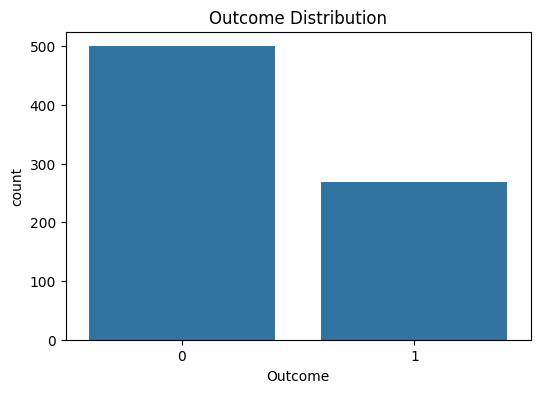

In [62]:
plt.figure(figsize=(6,4))
sns.countplot(x="Outcome", data=df)
plt.title("Outcome Distribution")
plt.show()

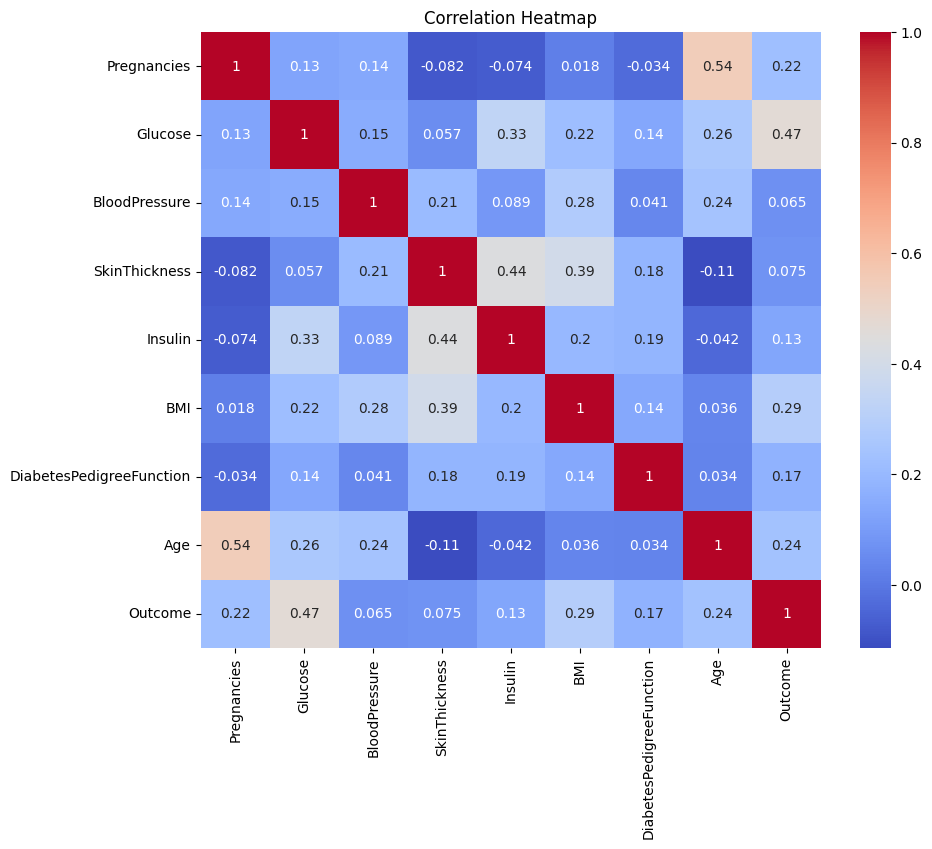

In [63]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [64]:
numerical_cols = df.columns[:-1]

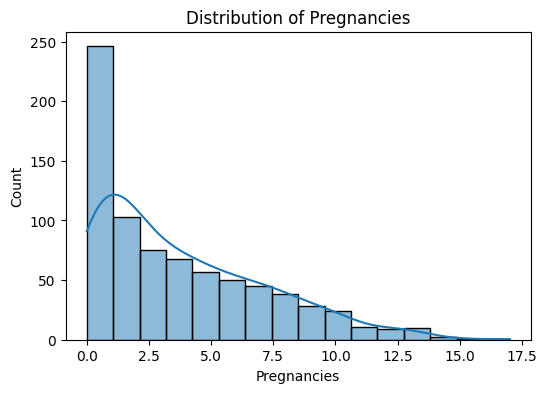

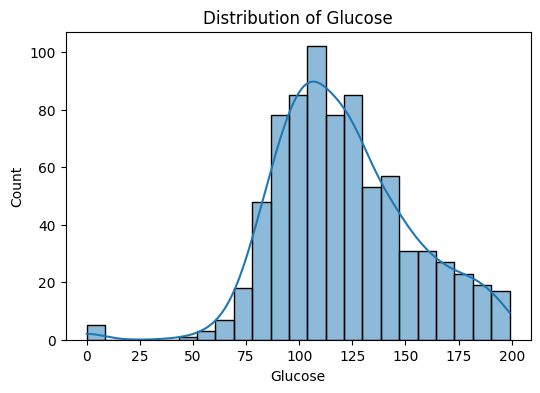

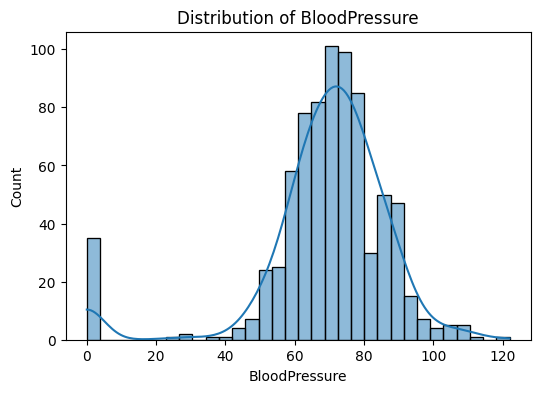

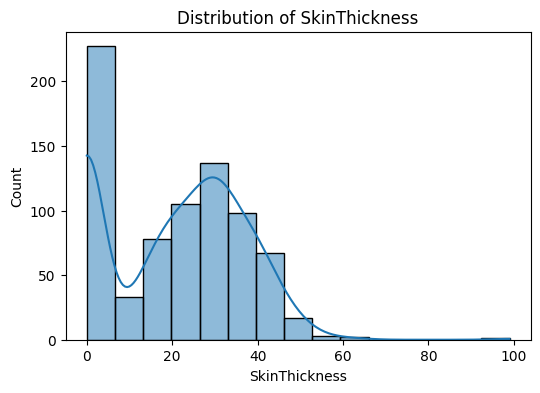

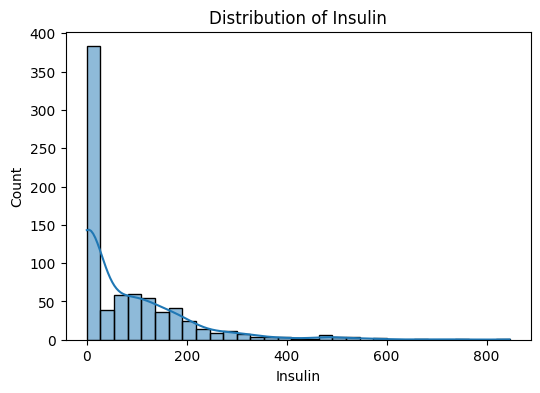

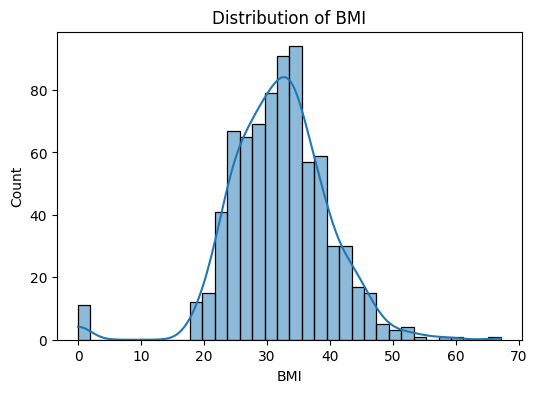

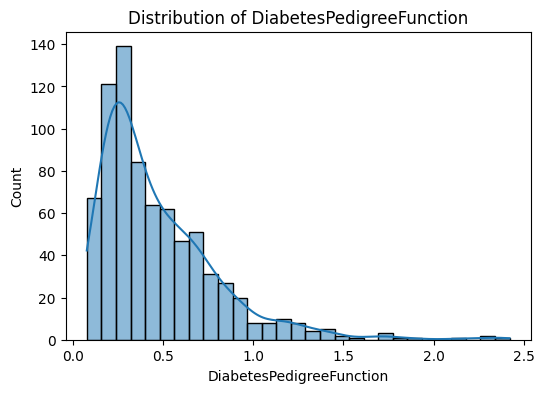

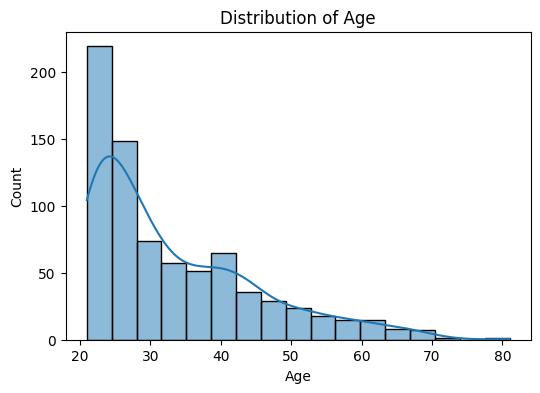

In [65]:
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

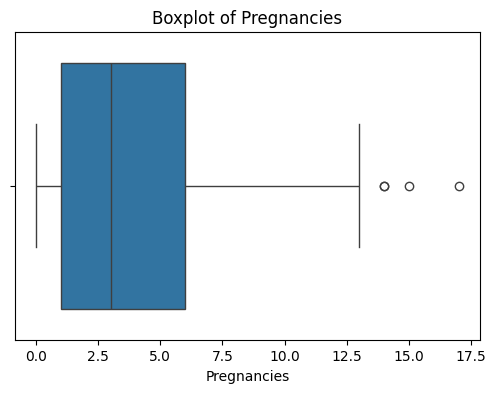

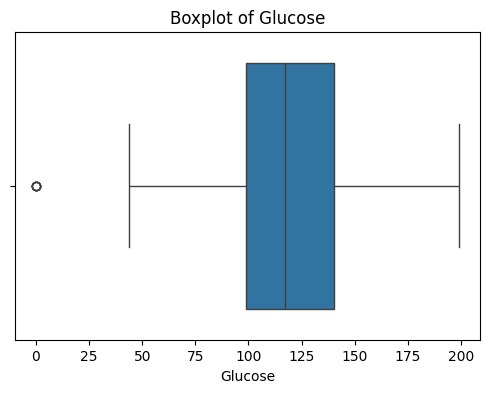

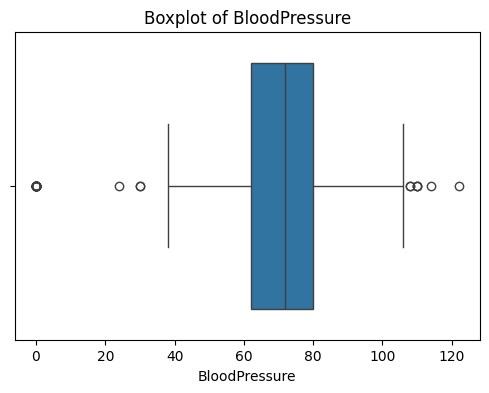

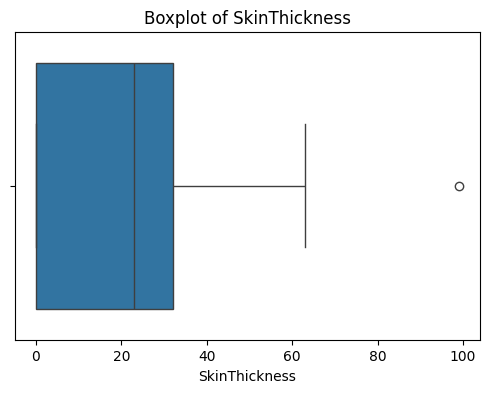

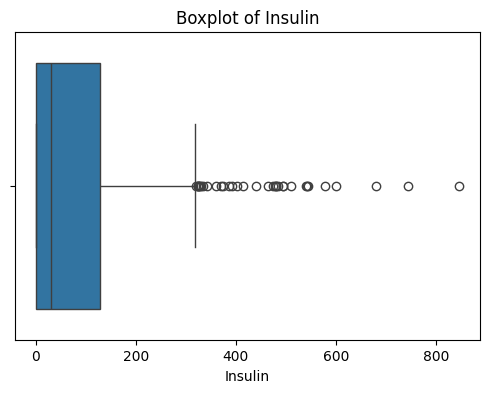

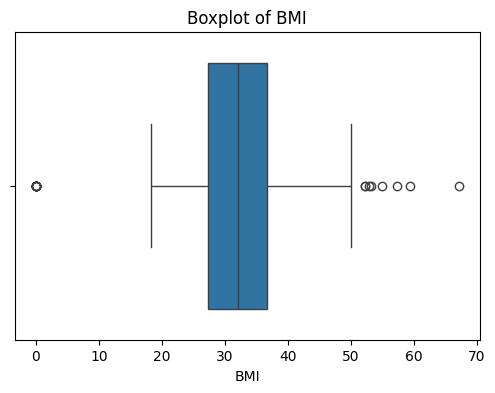

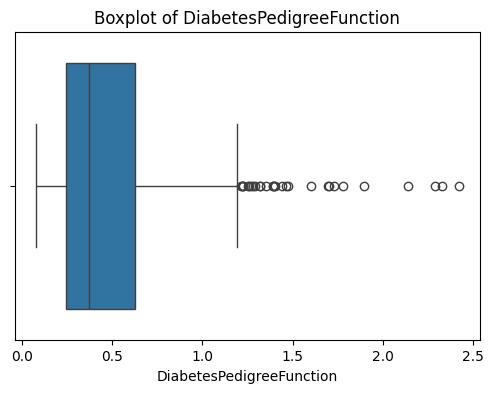

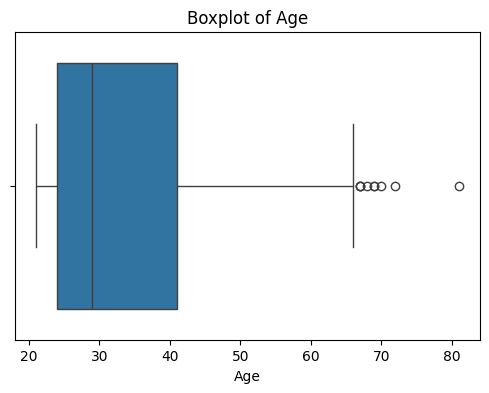

In [66]:
for col in numerical_cols:

    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## PREPROCESSING

In [67]:
cols_with_zero = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

In [68]:
df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

In [42]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [71]:
numerical_cols = list(range(X.shape[1]))

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_cols)
])

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [73]:
print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (614, 8)
Test Shape: (154, 8)


## Model

In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

#### Loggistic Regression:-

In [81]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=2000))
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:,1]

In [82]:
print("Accuracy:",accuracy_score(y_test,y_pred_lr))
print("Precision:",precision_score(y_test,y_pred_lr))
print("Recall:",recall_score(y_test,y_pred_lr))
print("F1 Score:",f1_score(y_test,y_pred_lr))

Accuracy: 0.7077922077922078
Precision: 0.6
Recall: 0.5
F1 Score: 0.5454545454545454


In [83]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=200,random_state=42))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:,1]

In [84]:
print("Accuracy:",accuracy_score(y_test,y_pred_rf))
print("Precision:",precision_score(y_test,y_pred_rf))
print("Recall:",recall_score(y_test,y_pred_rf))
print("F1 Score:",f1_score(y_test,y_pred_rf))

Accuracy: 0.7402597402597403
Precision: 0.6521739130434783
Recall: 0.5555555555555556
F1 Score: 0.6


In [91]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
    ))
])

xgb_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:,1]

In [92]:
print("Accuracy:",accuracy_score(y_test,y_pred_xgb))
print("Precision:",precision_score(y_test,y_pred_xgb))
print("Recall:",recall_score(y_test,y_pred_xgb))
print("F1 Score:",f1_score(y_test,y_pred_xgb))

Accuracy: 0.7662337662337663
Precision: 0.6956521739130435
Recall: 0.5925925925925926
F1 Score: 0.64


In [93]:
results = pd.DataFrame({
    "Model":["Logistic Regression","Random Forest","XGBoost"],
    "Accuracy":[accuracy_score(y_test,y_pred_lr),accuracy_score(y_test,y_pred_rf), accuracy_score(y_test,y_pred_xgb)],
    "Precision":[precision_score(y_test,y_pred_lr),precision_score(y_test,y_pred_rf),precision_score(y_test,y_pred_xgb)],
    "Recall":[recall_score(y_test,y_pred_lr),recall_score(y_test,y_pred_rf),recall_score(y_test,y_pred_xgb)],
    "F1":[f1_score(y_test,y_pred_lr),f1_score(y_test,y_pred_rf),f1_score(y_test,y_pred_xgb)]
})

results.sort_values(by="Accuracy",ascending=False)

,Model,Accuracy,Precision,Recall,F1
2,XGBoost,0.766234,0.695652,0.592593,0.640000
1,Random Forest,0.740260,0.652174,0.555556,0.600000
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455


In [94]:
import joblib

joblib.dump(xgb_pipeline,"diabetes_model.pkl")

['diabetes_model.pkl']